In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold

from rdkit import Chem

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# 298 K

In [2]:
# conductivity data
Full_data = pd.read_pickle(r"../Databases/Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data = Full_data[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion',
    ]]

data = data.dropna() # dropna is used to remove/eliminate any data without info
data = data.loc[data['Temperature'] == 298] #.loc is used to find these values
data = data.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion']) # drops duplicat data points
data = data.reset_index(drop=True)

molcond_scalar = StandardScaler(with_mean=False, with_std=False)
data['Normalized Cond'] = molcond_scalar.fit_transform(data['molarCond_Scm2mol'].to_numpy().reshape(-1,1))

data.loc[data['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'

In [3]:
# Electrostatic groups Bit Matrix

cations = data[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions = data[['Smiles_anion']]
subs_list = pd.read_csv(r"../Databases/IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

# Function to create Bit Vector of electrostatic groups
def substruct_matrix(subs_list, smiles):
    Bit_Matrix = np.zeros((len(smiles),len(subs_list)))
    count_1 = 0 
    for index, row in subs_list.iterrows():
        i = row[subs_list.columns[1]] # 'SMILES Cations/Anions:'
        j = row[subs_list.columns[2]] # 'Other representations:' (relevant resonance structures)
        count_2 = 0
        for k in smiles[smiles.columns[0]]: # iterating through each SMILES string
            mol = Chem.MolFromSmiles(k) # setting molecule for iteration
            if (mol.HasSubstructMatch(Chem.MolFromSmarts(i)) == True) | (mol.HasSubstructMatch(Chem.MolFromSmarts(j)) == True): # Checks for substructure match on either structure
                Bit_Matrix[count_2][count_1] = 1 # if match, then this position in Bit_Matrix is 1
            else:
                Bit_Matrix[count_2][count_1] = 0 # if no match, then this position in Bit_Matrix is 0
            count_2 = count_2 + 1
        count_1 = count_1 + 1
    return(Bit_Matrix)


Bit_Matrix_Cat = pd.DataFrame(substruct_matrix(subs_list,cations))
Bit_Matrix_An = pd.DataFrame(substruct_matrix(subs_list,anions))

Bit_Matrix_Cat.columns = [str(i) + '_c' for i in (np.arange(0,subs_list.shape[0],1))]
Bit_Matrix_An.columns = [str(i) + '_a' for i in (np.arange(0,subs_list.shape[0],1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df = pd.concat([pd.DataFrame(Bit_Matrix_Cat, columns=[str(i) + '_c' for i in (np.arange(0,subs_list.shape[0],1))], index=np.arange(0,182,1)), pd.DataFrame(Bit_Matrix_An, columns=[str(i) + '_a' for i in (np.arange(0,subs_list.shape[0],1))],  index=np.arange(0,182,1))],axis=1, join='inner')
Bit_Matrix_Short = Bit_Matrix_ES_df.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]#.merge(Bit_Matrix_ES_df.loc[:,'7_c'], left_index=True, right_index=True)




cat_subs = subs_list.copy()
an_subs = subs_list.copy()

cat_subs[['Name_clean']] = cat_subs[['Name:']]
an_subs[['Name_clean']] = ' ' + an_subs[['Name:']]

cat_subs[['Name:']] = cat_subs[['Name:']] + str('_c')
an_subs[['Name:']] = an_subs[['Name:']] + str('_a')

cat_subs[['Ion']] = 0
an_subs[['Ion']] = 1

subs = pd.concat((cat_subs, an_subs)).reset_index(drop=True)

Bit_index = Bit_Matrix_ES_df.T.reset_index(drop=True)
Names_df = subs.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')

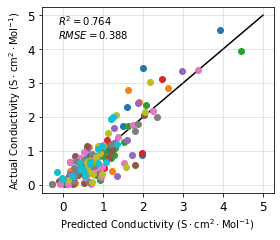

In [4]:
seed = 0

X = Bit_Matrix_Short
y = data[['Normalized Cond']]

k_fold = int(10)

train_indices = [0.0]*k_fold
test_indices = [0.0]*k_fold

Train_Input = [[]]*k_fold
Train_Target = [[]]*k_fold
Test_Input = [[]]*k_fold
Test_Target = [[]]*k_fold
Test_CompStrings = [[]]*k_fold
Test_NernstEinstein = [[]]*k_fold
Test_Temperature = [[]]*k_fold

i = 0
gss = GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed)

for train_idx, test_idx in gss.split(X, y, data['compString']):
    train_indices[i] = train_idx
    test_indices[i] = test_idx

    Train_Input[i] = X.iloc[train_indices[i].tolist(),:].values
    Train_Target[i] = y.iloc[train_indices[i].tolist(),:].values

    Test_Input[i] = X.iloc[test_indices[i].tolist(),:].values
    Test_Target[i] = y.iloc[test_indices[i].tolist(),:].values
    Test_CompStrings[i] = data[['compString']].iloc[test_indices[i].tolist(),:].values
    # Test_Temperature[i] = data[['Temperature']].iloc[test_indices[i].tolist(),:].values
    i += 1

Train_Pred = [[]]*k_fold
Test_Pred = [[]]*k_fold
Train_r2 = [0.0]*k_fold
Test_r2 = [0.0]*k_fold
Train_mse = [0.0]*k_fold
Test_mse = [0.0]*k_fold

for tset in range(0,k_fold):
    Svm = SVR(kernel='rbf',C=10, epsilon=0.1)

    # Training set
    Svm.fit(Train_Input[tset], Train_Target[tset].reshape(Train_Target[tset].shape[0],)) 
    Train_Pred[tset] = Svm.predict(Train_Input[tset]) # training predicted condc
    Test_Pred[tset] = Svm.predict(Test_Input[tset]) # test predicted cond
    Train_r2[tset] = r2_score(Train_Target[tset], Train_Pred[tset]) # r^2 score, training
    Test_r2[tset] = r2_score(Test_Target[tset], Test_Pred[tset]) # r^2 score, testing
    Train_mse[tset] = mean_squared_error(Train_Target[tset], Train_Pred[tset]) # r^2 score, training
    Test_mse[tset] = mean_squared_error(Test_Target[tset], Test_Pred[tset]) # r^2 score, testing


fig,ax2=plt.subplots(1,figsize=(4,3.5), facecolor='white')

ax2.grid(color='gray',axis='both',alpha=0.25)
ax2.set_axisbelow(True)
ax2.tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=12)
ax2.set_facecolor('w')

plt.plot([0,5], [0,5], c='k', zorder=0)
for tset in range(0,k_fold):
    plt.scatter(Test_Pred[tset], Test_Target[tset], zorder=1)
plt.annotate('$R^2=$'+str(np.round(r2_score(np.concatenate(Test_Target), np.concatenate(Test_Pred)), 3)), (0.2,0.85), xycoords='figure fraction')
plt.annotate('$RMSE=$'+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Test_Target), np.concatenate(Test_Pred))), 3)), (0.2,0.8), xycoords='figure fraction')
plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.tight_layout()
# plt.savefig('../Final Figures/Test_20CV.png', dpi=600)
plt.show()

# for tset in range(0,k_fold):
#     plt.plot([0,5], [0,5], c='k')
#     plt.scatter(Test_Pred[tset], Test_Target[tset])
#     plt.annotate('$R^2=$'+str(np.round(Test_r2[tset], 3)), (0.15,0.8), xycoords='figure fraction')
#     plt.annotate('$MSE=$'+str(np.round(Test_mse[tset], 3)), (0.15,0.75), xycoords='figure fraction')
#     plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
#     plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
#     plt.show()

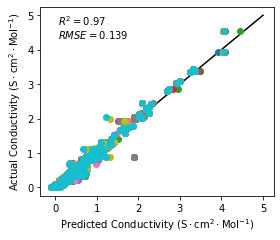

In [5]:
fig,ax2=plt.subplots(1,figsize=(4,3.5), facecolor='white')

plt.plot([0,5], [0,5], c='k', zorder=0)
for tset in range(0,k_fold):
    plt.scatter(Train_Pred[tset], Train_Target[tset], zorder=1)
plt.annotate('$R^2=$'+str(np.round(r2_score(np.concatenate(Train_Target), np.concatenate(Train_Pred)), 3)), (0.2,0.85), xycoords='figure fraction')
plt.annotate('$RMSE=$'+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Train_Target), np.concatenate(Train_Pred))), 3)), (0.2,0.8), xycoords='figure fraction')
plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.tight_layout()
#plt.savefig('../Final Figures/Test_Temp_20CV.png', dpi=600)
plt.show()

# Temp

In [6]:
# conductivity data
Full_data_T = pd.read_pickle(r"../Databases/Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data_T = Full_data_T[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion',
    ]]

data_T = data_T.copy().dropna() # dropna is used to remove/eliminate any data without info
data_T = data_T.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion', 'Temperature']) # drops duplicat data points
data_T = data_T.reset_index(drop=True)

molcond_scalar_T = StandardScaler(with_mean=False, with_std=False)
data_T['Normalized Cond'] = molcond_scalar_T.fit_transform(data_T['molarCond_Scm2mol'].to_numpy().reshape(-1,1))

data_T = data[['compString']].merge(data_T, on=['compString'], how='left').drop_duplicates(subset=['Smiles_cation', 'Smiles_anion', 'Temperature'])

data_T.loc[data_T['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'

In [7]:
# Electrostatic groups Bit Matrix

cations_T = data_T[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions_T = data_T[['Smiles_anion']]
subs_list_T = pd.read_csv(r"../Databases/IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

# Function to create Bit Vector of electrostatic groups
def substruct_matrix(subs_list, smiles):
    Bit_Matrix = np.zeros((len(smiles),len(subs_list)))
    count_1 = 0 
    for index, row in subs_list.iterrows():
        i = row[subs_list.columns[1]] # 'SMILES Cations/Anions:'
        j = row[subs_list.columns[2]] # 'Other representations:' (relevant resonance structures)
        count_2 = 0
        for k in smiles[smiles.columns[0]]: # iterating through each SMILES string
            mol = Chem.MolFromSmiles(k) # setting molecule for iteration
            if (mol.HasSubstructMatch(Chem.MolFromSmarts(i)) == True) | (mol.HasSubstructMatch(Chem.MolFromSmarts(j)) == True): # Checks for substructure match on either structure
                Bit_Matrix[count_2][count_1] = 1 # if match, then this position in Bit_Matrix is 1
            else:
                Bit_Matrix[count_2][count_1] = 0 # if no match, then this position in Bit_Matrix is 0
            count_2 = count_2 + 1
        count_1 = count_1 + 1
    return(Bit_Matrix)


Bit_Matrix_Cat_T = pd.DataFrame(substruct_matrix(subs_list_T,cations_T))
Bit_Matrix_An_T = pd.DataFrame(substruct_matrix(subs_list_T,anions_T))

Bit_Matrix_Cat_T.columns = [str(i) + '_c' for i in (np.arange(0,subs_list_T.shape[0],1))]
Bit_Matrix_An_T.columns = [str(i) + '_a' for i in (np.arange(0,subs_list_T.shape[0],1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df_T = pd.concat([pd.DataFrame(Bit_Matrix_Cat_T, columns=[str(i) + '_c' for i in (np.arange(0,subs_list_T.shape[0],1))], index=np.arange(0,data_T.shape[0],1)), pd.DataFrame(Bit_Matrix_An_T, columns=[str(i) + '_a' for i in (np.arange(0,subs_list_T.shape[0],1))],  index=np.arange(0,data_T.shape[0],1))],axis=1, join='inner')
Bit_Matrix_Short_Ta = Bit_Matrix_ES_df_T.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]#.merge(Bit_Matrix_ES_df_T.loc[:,'7_c'], left_index=True, right_index=True)


scaleT = StandardScaler()
Bit_Matrix_Short_T = pd.concat([Bit_Matrix_Short_Ta, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]))],axis=1, join='inner')
Bit_Matrix_Short_T

cat_subs_T = subs_list_T.copy()
an_subs_T = subs_list_T.copy()

cat_subs_T[['Name_clean']] = cat_subs_T[['Name:']]
an_subs_T[['Name_clean']] = ' ' + an_subs_T[['Name:']]

cat_subs_T[['Name:']] = cat_subs_T[['Name:']] + str('_c')
an_subs_T[['Name:']] = an_subs_T[['Name:']] + str('_a')

cat_subs_T[['Ion']] = 0
an_subs_T[['Ion']] = 1

subs_T = pd.concat((cat_subs_T, an_subs_T)).reset_index(drop=True)

Bit_index_T = Bit_Matrix_ES_df.T.reset_index(drop=True)
Names_df_T = subs_T.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs_T.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')
Names_df_T.loc[Names_df_T.shape[0]+1] = ['Temperature', '', '','', 2]

/var/folders/n0/8fxhskld1wsc76dqzmh0f_9w0000gn/T/ipykernel_86883/1245765686.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Names_df_T.loc[Names_df_T.shape[0]+1] = ['Temperature', '', '','', 2]


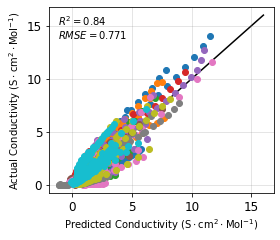

In [8]:
seed = 0

X_T = Bit_Matrix_Short_T
y_T = data_T[['Normalized Cond']]

k_fold = int(10)

train_indices_T = [0.0]*k_fold
test_indices_T = [0.0]*k_fold

Train_Input_T = [[]]*k_fold
Train_Target_T = [[]]*k_fold
Test_Input_T = [[]]*k_fold
Test_Target_T = [[]]*k_fold
Test_CompStrings_T = [[]]*k_fold
Test_NernstEinstein_T = [[]]*k_fold
Test_Temperature_T = [[]]*k_fold

i = 0
gss_T = GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed)

for train_idx, test_idx in gss_T.split(X_T, y_T, data_T['compString']):
    train_indices_T[i] = train_idx
    test_indices_T[i] = test_idx

    Train_Input_T[i] = X_T.iloc[train_indices_T[i].tolist(),:].values
    Train_Target_T[i] = y_T.iloc[train_indices_T[i].tolist(),:].values

    Test_Input_T[i] = X_T.iloc[test_indices_T[i].tolist(),:].values
    Test_Target_T[i] = y_T.iloc[test_indices_T[i].tolist(),:].values
    Test_CompStrings_T[i] = data_T[['compString']].iloc[test_indices_T[i].tolist(),:].values
    Test_Temperature[i] = data_T[['Temperature']].iloc[test_indices_T[i].tolist(),:].values
    i += 1

Train_Pred_T = [[]]*k_fold
Test_Pred_T = [[]]*k_fold
Train_r2_T = [0.0]*k_fold
Test_r2_T = [0.0]*k_fold
Train_mse_T = [0.0]*k_fold
Test_mse_T = [0.0]*k_fold

for tset in range(0,k_fold):
    Svm = SVR(kernel='rbf',C=10, epsilon=0.1)

    # Training set
    Svm.fit(Train_Input_T[tset], Train_Target_T[tset].reshape(Train_Target_T[tset].shape[0],)) 
    Train_Pred_T[tset] = Svm.predict(Train_Input_T[tset]) # training predicted condc
    Test_Pred_T[tset] = Svm.predict(Test_Input_T[tset]) # test predicted cond
    Train_r2_T[tset] = r2_score(Train_Target_T[tset], Train_Pred_T[tset]) # r^2 score, training
    Test_r2_T[tset] = r2_score(Test_Target_T[tset], Test_Pred_T[tset]) # r^2 score, testing
    Train_mse_T[tset] = mean_squared_error(Train_Target_T[tset], Train_Pred_T[tset]) # r^2 score, training
    Test_mse_T[tset] = mean_squared_error(Test_Target_T[tset], Test_Pred_T[tset]) # r^2 score, testing


fig,ax2=plt.subplots(1,figsize=(4,3.5), facecolor='white')

ax2.grid(color='gray',axis='both',alpha=0.25)
ax2.set_axisbelow(True)
ax2.tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=12)
ax2.set_facecolor('w')

plt.plot([0,16], [0,16], c='k', zorder=0)
for tset in range(0,k_fold):
    plt.scatter(Test_Pred_T[tset], Test_Target_T[tset], zorder=1)
plt.annotate('$R^2=$'+str(np.round(r2_score( np.concatenate(Test_Target_T), np.concatenate(Test_Pred_T)), 3)), (0.2,0.85), xycoords='figure fraction')
plt.annotate('$RMSE=$'+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Test_Target_T), np.concatenate(Test_Pred_T))), 3)), (0.2,0.8), xycoords='figure fraction')
plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.tight_layout()
# plt.savefig('../Final Figures/Test_Temp_20CV.png', dpi=600)
plt.show()

# for tset in range(0,k_fold):
#     plt.plot([0,5], [0,5], c='k')
#     plt.scatter(Test_Pred[tset], Test_Target[tset])
#     plt.annotate('$R^2=$'+str(np.round(Test_r2[tset], 3)), (0.15,0.8), xycoords='figure fraction')
#     plt.annotate('$MSE=$'+str(np.round(Test_mse[tset], 3)), (0.15,0.75), xycoords='figure fraction')
#     plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
#     plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
#     plt.show()

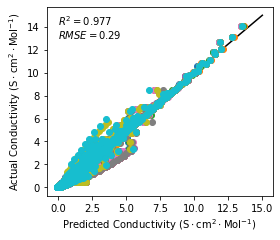

In [9]:
fig,ax2=plt.subplots(1,figsize=(4,3.5), facecolor='white')

plt.plot([0,15], [0,15], c='k', zorder=0)
for tset in range(0,k_fold):
    plt.scatter(Train_Pred_T[tset], Train_Target_T[tset], zorder=1)
plt.annotate('$R^2=$'+str(np.round(r2_score(np.concatenate(Train_Target_T), np.concatenate(Train_Pred_T)), 3)), (0.2,0.85), xycoords='figure fraction')
plt.annotate('$RMSE=$'+str(np.round(np.sqrt(mean_squared_error( np.concatenate(Train_Target_T), np.concatenate(Train_Pred_T))), 3)), (0.2,0.8), xycoords='figure fraction')
plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)
plt.tight_layout()
#plt.savefig('../Final Figures/Test_Temp_20CV.png', dpi=600)
plt.show()

# Parity Plots

Imidazolium Bis(sulfonyl)imide
Imidazolium Sulfonate
Imidazolium Cyanide
Imidazolium Boroanion
Imidazolium Other
Pyrrolidinium Bis(sulfonyl)imide
Pyrrolidinium Sulfonate
Pyrrolidinium Cyanide
Pyrrolidinium Boroanion
Pyrrolidinium Other
Pyridinium Bis(sulfonyl)imide
Pyridinium Sulfonate
Pyridinium Cyanide
Pyridinium Boroanion
Pyridinium Other
Other Bis(sulfonyl)imide
Other Sulfonate
Other Cyanide
Other Boroanion
Other Other


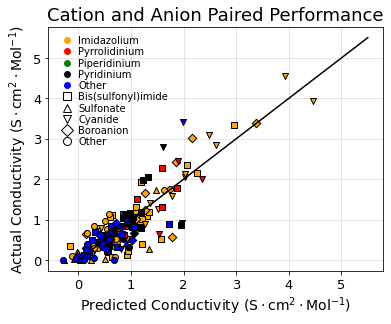

In [10]:
an_cat_labels = pd.DataFrame(np.concatenate(Test_Input), columns=Bit_Matrix_Short.columns)

fig,ax2=plt.subplots(1,figsize=(6,4.5), facecolor='white')

ax2.grid(color='gray',axis='both',alpha=0.25)
ax2.set_axisbelow(True)
ax2.tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=12)
ax2.set_facecolor('w')

cation_colors = {
    'Imidazolium': 'orange',
    'Pyrrolidinium': 'red',
    'Piperidinium': 'green',
    'Pyridinium': 'black',
    'Other': 'blue',
}

anion_shapes = {

    'Bis(sulfonyl)imide': 's',      # Square
    'Sulfonate': '^',     # Triangle up
    'Cyanide': 'v',     # Triangle down
    'Boroanion': 'D',    # Diamond
    'Other': 'o',    # Circle

}

# cation plot mapping
cation_map = {

    'Imidazolium': ((an_cat_labels['5_c'] == 1) & (an_cat_labels['12_c'] != 1)),
    'Pyrrolidinium': an_cat_labels['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels['8_c'] == 1,
    'Other': ~an_cat_labels[['5_c', '4_c', '8_c']].any(axis=1)

}

# anion plot mapping
anion_map = {

    'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
    'Sulfonate': an_cat_labels['38_a'] == 1,
    'Cyanide': an_cat_labels['39_a'] == 1,
    'Boroanion': an_cat_labels['45_a'] == 1,
    'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '45_a']].any(axis=1),
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        print(cation, anion)
        mask = cation_mask & anion_mask
        plt.scatter(pd.DataFrame(np.concatenate(Test_Pred).ravel())[mask], 
                    pd.DataFrame(np.concatenate(Test_Target).ravel())[mask], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1
                    )

plt.plot([0,5.5], [0, 5.5], color='black')
plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 14)
plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
    legend_handles.append(handle)
    legend_labels.append(cation)

# anions:
for anion, shape in anion_shapes.items():
    handle = plt.Line2D([0], [0], marker=shape, color='white', linestyle='None', markersize=10,markeredgecolor='black')
    legend_handles.append(handle)
    legend_labels.append(anion)

# LEGEND???
plt.legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=10, markerscale=0.8, labelspacing=0.125, handletextpad=0.1, ncol=1, columnspacing=0, loc=2)

#plt.savefig('Cats_Ans_leg.png',bbox_inches='tight')
plt.show()


Imidazolium Bis(sulfonyl)imide
Imidazolium Sulfonate
Imidazolium Cyanide
Imidazolium Boroanion
Imidazolium Other
Pyrrolidinium Bis(sulfonyl)imide
Pyrrolidinium Sulfonate
Pyrrolidinium Cyanide
Pyrrolidinium Boroanion
Pyrrolidinium Other
Pyridinium Bis(sulfonyl)imide
Pyridinium Sulfonate
Pyridinium Cyanide
Pyridinium Boroanion
Pyridinium Other
Other Bis(sulfonyl)imide
Other Sulfonate
Other Cyanide
Other Boroanion
Other Other


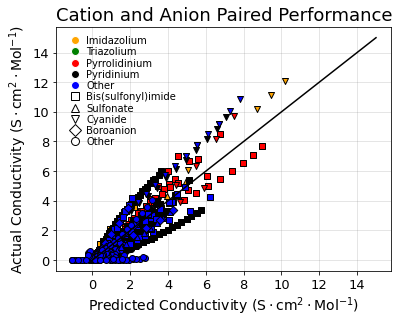

In [11]:
an_cat_labels_T = pd.DataFrame(np.concatenate(Test_Input_T), columns=Bit_Matrix_Short_T.columns)

fig,ax2=plt.subplots(1,figsize=(6,4.5), facecolor='white')

ax2.grid(color='gray',axis='both',alpha=0.25)
ax2.set_axisbelow(True)
ax2.tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=12)
ax2.set_facecolor('w')

cation_colors = {
    'Imidazolium': 'orange',
    'Triazolium': 'green',
    'Pyrrolidinium': 'red',
    #'Piperidinium': 'green',
    'Pyridinium': 'black',
    'Other': 'blue',
}

anion_shapes = {

    'Bis(sulfonyl)imide': 's',      # Square
    'Sulfonate': '^',     # Triangle up
    'Cyanide': 'v',     # Triangle down
    'Boroanion': 'D',    # Diamond
    'Other': 'o',    # Circle

}

# cation plot mapping
cation_map = {

    'Imidazolium': an_cat_labels['5_c'] == 1,
    #'Triazolium': an_cat_labels['12_c'] == 1,
    'Pyrrolidinium': an_cat_labels_T['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels_T['8_c'] == 1,
    'Other': ~an_cat_labels_T[['5_c', '4_c', '8_c', '12_c']].any(axis=1)

}

# anion plot mapping
anion_map = {

    'Bis(sulfonyl)imide': an_cat_labels_T['37_a'] == 1,
    'Sulfonate': an_cat_labels_T['38_a'] == 1,
    'Cyanide': an_cat_labels_T['39_a'] == 1,
    'Boroanion': an_cat_labels_T['45_a'] == 1,
    'Other': ~an_cat_labels_T[['37_a', '38_a', '39_a', '45_a']].any(axis=1),
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        print(cation, anion)
        mask = cation_mask & anion_mask
        plt.scatter(pd.DataFrame(np.concatenate(Test_Pred_T).ravel())[mask], 
                    pd.DataFrame(np.concatenate(Test_Target_T).ravel())[mask], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1
                    )

plt.plot([0, 15], [0, 15], color='black')
plt.xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 14)
plt.ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
    legend_handles.append(handle)
    legend_labels.append(cation)

# anions:
for anion, shape in anion_shapes.items():
    handle = plt.Line2D([0], [0], marker=shape, color='white', linestyle='None', markersize=10,markeredgecolor='black')
    legend_handles.append(handle)
    legend_labels.append(anion)

# LEGEND???
plt.legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=10, markerscale=0.8, labelspacing=0.125, handletextpad=0.1, ncol=1, columnspacing=0, loc=2)

#plt.savefig('Cats_Ans_leg.png',bbox_inches='tight')
plt.show()


Imidazolium Bis(sulfonyl)imide
Imidazolium Sulfonate
Imidazolium Cyanide
Imidazolium Boroanion
Imidazolium Other
Pyrrolidinium Bis(sulfonyl)imide
Pyrrolidinium Sulfonate
Pyrrolidinium Cyanide
Pyrrolidinium Boroanion
Pyrrolidinium Other
Pyridinium Bis(sulfonyl)imide
Pyridinium Sulfonate
Pyridinium Cyanide
Pyridinium Boroanion
Pyridinium Other
Other Bis(sulfonyl)imide
Other Sulfonate
Other Cyanide
Other Boroanion
Other Other
Imidazolium Bis(sulfonyl)imide
Imidazolium Sulfonate
Imidazolium Cyanide
Imidazolium Boroanion
Imidazolium Other
Pyrrolidinium Bis(sulfonyl)imide
Pyrrolidinium Sulfonate
Pyrrolidinium Cyanide
Pyrrolidinium Boroanion
Pyrrolidinium Other
Pyridinium Bis(sulfonyl)imide
Pyridinium Sulfonate
Pyridinium Cyanide
Pyridinium Boroanion
Pyridinium Other
Other Bis(sulfonyl)imide
Other Sulfonate
Other Cyanide
Other Boroanion
Other Other


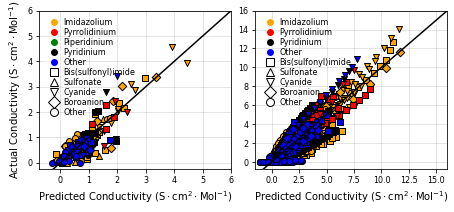

In [12]:
an_cat_labels_T = pd.DataFrame(np.concatenate(Test_Input_T), columns=Bit_Matrix_Short_T.columns)

fig,ax2=plt.subplot_mosaic('AB',figsize=(7.0866, 2.75), facecolor='white')




an_cat_labels = pd.DataFrame(np.concatenate(Test_Input), columns=Bit_Matrix_Short.columns)

ax2['A'].grid(color='gray',axis='both',alpha=0.25)
ax2['A'].set_axisbelow(True)
ax2['A'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['A'].set_facecolor('w')

cation_colors = {
    'Imidazolium': 'orange',
    'Pyrrolidinium': 'red',
    'Piperidinium': 'green',
    'Pyridinium': 'black',
    'Other': 'blue',
}

anion_shapes = {

    'Bis(sulfonyl)imide': 's',      # Square
    'Sulfonate': '^',     # Triangle up
    'Cyanide': 'v',     # Triangle down
    'Boroanion': 'D',    # Diamond
    'Other': 'o',    # Circle

}

# cation plot mapping
cation_map = {

    'Imidazolium': an_cat_labels['5_c'] == 1,
    'Pyrrolidinium': an_cat_labels['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels['8_c'] == 1,
    'Other': ~an_cat_labels[['5_c', '4_c', '8_c']].any(axis=1)

}

# anion plot mapping
anion_map = {

    'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
    'Sulfonate': an_cat_labels['38_a'] == 1,
    'Cyanide': an_cat_labels['39_a'] == 1,
    'Boroanion': an_cat_labels['45_a'] == 1,
    'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '45_a']].any(axis=1),
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        print(cation, anion)
        mask = cation_mask & anion_mask
        ax2['A'].scatter(pd.DataFrame(np.concatenate(Test_Pred).ravel())[mask], 
                    pd.DataFrame(np.concatenate(Test_Target).ravel())[mask], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1
                    )

ax2['A'].plot([-1,6], [-1, 6], color='black')
ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)
ax2['A'].set_xlim(-0.75,6)
ax2['A'].set_ylim(-0.25,6)
#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
    legend_handles.append(handle)
    legend_labels.append(cation)

# anions:
for anion, shape in anion_shapes.items():
    handle = plt.Line2D([0], [0], marker=shape, color='white', linestyle='None', markersize=10,markeredgecolor='black')
    legend_handles.append(handle)
    legend_labels.append(anion)

# LEGEND???
ax2['A'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.8, labelspacing=0.125, handletextpad=0.1, ncol=1, columnspacing=0, loc=2)




ax2['B'].grid(color='gray',axis='both',alpha=0.25)
ax2['B'].set_axisbelow(True)
ax2['B'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['B'].set_facecolor('w')
ax2['B'].set_xlim(-1.5,16)
ax2['B'].set_ylim(-0.75,16)

cation_colors = {
    'Imidazolium': 'orange',
    'Pyrrolidinium': 'red',
    #'Piperidinium': 'green',
    'Pyridinium': 'black',
    'Other': 'blue',
}

anion_shapes = {

    'Bis(sulfonyl)imide': 's',      # Square
    'Sulfonate': '^',     # Triangle up
    'Cyanide': 'v',     # Triangle down
    'Boroanion': 'D',    # Diamond
    'Other': 'o',    # Circle

}

# cation plot mapping
cation_map = {

    'Imidazolium': an_cat_labels_T['5_c'] == 1,
    'Pyrrolidinium': an_cat_labels_T['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels_T['8_c'] == 1,
    'Other': ~an_cat_labels_T[['5_c', '4_c', '8_c']].any(axis=1)

}

# anion plot mapping
anion_map = {

    'Bis(sulfonyl)imide': an_cat_labels_T['37_a'] == 1,
    'Sulfonate': an_cat_labels_T['38_a'] == 1,
    'Cyanide': an_cat_labels_T['39_a'] == 1,
    'Boroanion': an_cat_labels_T['45_a'] == 1,
    'Other': ~an_cat_labels_T[['37_a', '38_a', '39_a', '45_a']].any(axis=1),
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        print(cation, anion)
        mask = cation_mask & anion_mask
        ax2['B'].scatter(pd.DataFrame(np.concatenate(Test_Pred_T).ravel())[mask], 
                    pd.DataFrame(np.concatenate(Test_Target_T).ravel())[mask], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1
                    )

ax2['B'].plot([-2, 16], [-2, 16], color='black')
ax2['B'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
#ax2['B'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
    legend_handles.append(handle)
    legend_labels.append(cation)

# anions:
for anion, shape in anion_shapes.items():
    handle = plt.Line2D([0], [0], marker=shape, color='white', linestyle='None', markersize=10,markeredgecolor='black')
    legend_handles.append(handle)
    legend_labels.append(anion)

# LEGEND???
ax2['B'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.8, labelspacing=0.125, handletextpad=0.1, ncol=1, columnspacing=0, loc=2)

plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.125, hspace=0.1)

#plt.savefig('../Final Figures/Cats_Ans_leg Both.png',bbox_inches='tight', dpi=600)
plt.show()


# Weights

In [13]:
Svm = SVR(kernel='rbf',C=1000, epsilon=0.1)
Svm.fit(X.to_numpy(),y)

ones = pd.DataFrame(np.identity(X.shape[1]))
bias = np.zeros(X.shape[1])

bias_val = Svm.predict(bias.reshape(1,-1))
weights = Svm.predict(ones) - bias_val

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [14]:
Svm = SVR(kernel='rbf',C=1000, epsilon=0.1)
Svm.fit(X_T.to_numpy(),y_T)

ones_T = pd.DataFrame(np.identity(X_T.shape[1]))
bias_T = np.zeros(X_T.shape[1])

bias_val_T = Svm.predict(bias_T.reshape(1,-1))
weights_T = Svm.predict(ones_T) - bias_val_T

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
Names_df_T.loc[37, 'Name_clean'] = 'Temperature'
weights_df_T = pd.DataFrame(data={'Names':Names_df_T['Name:'], 'Clean Names':Names_df_T['Name_clean'], 'Numbers':X_T.columns, 'Weights':weights_T, 'Ion':Names_df_T['Ion']})
Bias_df = pd.DataFrame(['Bias', 'Bias', 61, bias_val_T[0], 2]).T
Bias_df.columns = weights_df_T.columns
weights_df_T = pd.concat((weights_df_T, Bias_df.iloc[[0]]))
weights_df_sorted_T = weights_df_T.sort_values(by=['Weights'], ascending=[False])
weights_df_sorted_T = weights_df_sorted_T.sort_values(by=['Ion', 'Weights'], ascending=[True,False])
weights_df_sorted_T = weights_df_sorted_T.drop(37)

In [16]:
weights_df = pd.DataFrame(data={'Names':Names_df['Name:'], 'Clean Names':Names_df['Name_clean'], 'Numbers':X.columns, 'Weights':weights, 'Ion':Names_df['Ion']})
weights_df = pd.concat((weights_df, pd.DataFrame({'Names':'Bias', 'Clean Names':'Bias', 'Numbers':61, 'Weights':bias_val, 'Ion':2})))
weights_df_sorted = weights_df.sort_values(by=['Ion', 'Weights'], ascending=[True,False])

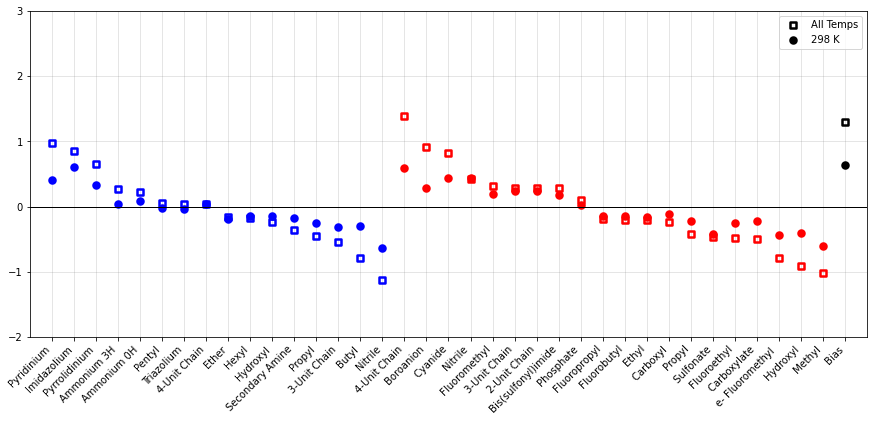

In [17]:
fig, ax = plt.subplots(1, figsize=(15, 6), facecolor='white')
ax.grid(color='gray', axis='both', alpha=0.25)
ax.set_axisbelow(True)

size_lw = 2.5

plt.plot([-1, 39], [0, 0], color='black', linewidth=1)
plt.scatter(weights_df_sorted_T['Clean Names'].iloc[0:16], weights_df_sorted_T['Weights'].iloc[0:16], c='None', marker='s', edgecolors='b', linewidths=size_lw)
plt.scatter(weights_df_sorted_T['Clean Names'].iloc[16:36], weights_df_sorted_T['Weights'].iloc[16:36], c='None', marker='s', edgecolors='r', linewidths=size_lw)
plt.scatter(weights_df_sorted_T['Clean Names'].iloc[36], weights_df_sorted_T['Weights'].iloc[36], c='None', label='All Temps', marker='s', edgecolors='k', linewidths=size_lw)

plt.scatter(weights_df_sorted['Clean Names'].iloc[0:16], weights_df_sorted['Weights'].iloc[0:16], c='b', marker='o', edgecolors='b', linewidths=size_lw)
plt.scatter(weights_df_sorted['Clean Names'].iloc[16:36], weights_df_sorted['Weights'].iloc[16:36], c='r', marker='o', edgecolors='r', linewidths=size_lw)
plt.scatter(weights_df_sorted['Clean Names'].iloc[36], weights_df_sorted['Weights'].iloc[36], c='k', label='298 K', marker='o', edgecolors='k', linewidths=size_lw)

plt.xlim(-1, 37)
plt.ylim(-2,3)

plt.xticks(rotation=45, ha='right')
plt.legend()

plt.show()

In [18]:
weights_df_sorted_T = weights_df_T.sort_values(by=['Ion', 'Weights'], ascending=[False,True])
weights_df_sorted_T = weights_df_sorted_T.drop(37)
weights_df_sorted = weights_df.sort_values(by=['Ion', 'Weights'], ascending=[False,True])

In [19]:
c_array_b = ['None', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']
c_array_r = ['None', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']

c_array_cat_an = ['k', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'r', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b']


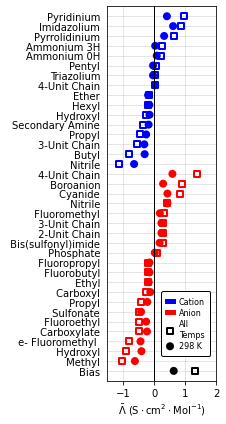

In [20]:
fig, ax = plt.subplots(1, figsize=(3.25, 6), facecolor='white')
ax.grid(color='gray', axis='both', alpha=0.25)
ax.set_axisbelow(True)

plt.plot([0, 0], [-1,38], color='black', linewidth=1)
plt.plot([],[], c='None', lw=5, label='Cation', marker='None')
plt.plot([],[], c='k', lw=5, label='Anion', marker='None')
plt.scatter(weights_df_sorted_T['Weights'], weights_df_sorted_T['Clean Names'], c='None', label='All\nTemps', marker='s', edgecolor=c_array_cat_an, linewidths=2)

plt.scatter(weights_df_sorted['Weights'], weights_df_sorted['Clean Names'], c=c_array_cat_an, label='298 K', edgecolor=c_array_cat_an, linewidths=2)


plt.xlim(-1.5,2)
plt.ylim(-1,37)

plt.xticks([-1,0,1,2], size=10)
plt.yticks(size=10)
ax.tick_params(left=False, bottom=True)
plt.xlabel('$\mathregular{ \\bar\Lambda}$ $\mathregular{ (S \cdot cm^{2} \cdot Mol^{-1}}$)', size=10)

#ax.legend(loc='upper right', bbox_to_anchor=(1, 0.95), framealpha=1.0, edgecolor='k', labelspacing=0.5, handletextpad=0, borderpad=0.25, fontsize=10)

ax = plt.gca()
leg = plt.legend(loc='upper right', bbox_to_anchor=(0.98, 0.25), framealpha=1.0, edgecolor='k', labelspacing=0.3, handletextpad=0.7, borderpad=0.7, fontsize=8, handlelength=0.75)

leg.legend_handles[0].set_color('blue')

leg.legend_handles[1].set_color('red')

plt.tight_layout()
plt.savefig('../Figures/RBf Kernel Weights.png', dpi=150)
plt.show()

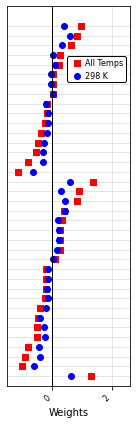

In [21]:
fig, ax = plt.subplots(1, figsize=(2, 6), facecolor='white')
ax.grid(color='gray', axis='both', alpha=0.25)
ax.set_axisbelow(True)

plt.plot([0, 0], [-1,38], color='black', linewidth=1)
plt.scatter(weights_df_sorted_T['Weights'], weights_df_sorted_T['Names'], c='r', label='All Temps', marker='s')
plt.scatter(weights_df_sorted['Weights'], weights_df_sorted['Names'], c='b', label='298 K')

plt.xlim(-1.5, 2.6)
plt.ylim(-1,38)

plt.xticks(rotation=45, ha='right', size=8)
ax.set_yticklabels([])
ax.tick_params(left=False, bottom=True)
plt.xlabel('Weights', size=10)
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.88), framealpha=1.0, edgecolor='k', labelspacing=0.5, handletextpad=0, borderpad=0.25, fontsize=8)
plt.tight_layout()
#plt.savefig('../Final Figures/Weights for Abstract.png', dpi=450)
plt.show()